# Estudo de Caso: Análise de Performance e Gerenciamento de Memória
**Disciplina:** Compiladores e Interpretadores  
**Objetivo:** Comparar o tempo de execução e o consumo de memória (Heap) entre uma linguagem interpretada (Python) e uma compilada AoT (C) durante um processo de alocação massiva de dados. O experimento simula cenários críticos de consumo de recursos em contêineres (*Cloud Native*).

In [ ]:
!pip install memory_profiler matplotlib seaborn
%load_ext memory_profiler

import os
import time
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns

# Garantindo que as pastas de destino existam
os.makedirs('../img', exist_ok=True)
os.makedirs('../src', exist_ok=True)

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


## 1. Implementação em Linguagem Interpretada (Python)
Linguagens interpretadas traduzem o código em tempo de execução e geralmente utilizam *Garbage Collectors* para gerenciamento automático de memória. O script abaixo aloca dinamicamente uma lista no *Heap*.

In [ ]:
# Algoritmo de estresse em Python
def stress_python():
    # Alocação de 10 milhões de inteiros no Heap
    tamanho = 10_000_000
    lista_gigante = [i for i in range(tamanho)]
    return len(lista_gigante)

print("--- Medindo Tempo de Execução (Python) ---")
tempo_python = %timeit -o -n 5 -r 3 stress_python()

print("\n--- Medindo Consumo de Memória (Python) ---")
memoria_python = %memit -o stress_python()

# Extraindo os valores para o gráfico
py_time_sec = tempo_python.average
py_mem_mb = memoria_python.mem_usage if isinstance(memoria_python.mem_usage, list) else memoria_python.mem_usage

--- Medindo Tempo de Execução (Python) ---
525 ms ± 4.46 ms per loop (mean ± std. dev. of 3 runs, 5 loops each)

--- Medindo Consumo de Memória (Python) ---
peak memory: 582.62 MiB, increment: 347.55 MiB


## 2. Implementação em Linguagem Compilada (C)
Linguagens compiladas (Ahead-of-Time) traduzem o código fonte para linguagem de máquina durante a fase de síntese (geração de código alvo). O gerenciamento do *Heap* é feito manualmente (funções `malloc` e `free`).

In [ ]:
%%writefile ../src/stress_test.c
#include <stdio.h>
#include <stdlib.h>

int main() {
    // Tamanho: 10 milhões de inteiros
    long long tamanho = 10000000;

    // Alocação manual de memória no Heap
    int *array_gigante = (int *)malloc(tamanho * sizeof(int));

    if (array_gigante == NULL) {
        printf("Erro: Out of Memory (OOM)\n");
        return 1;
    }

    // Preenchendo o array para garantir que o SO aloque as páginas de memória
    for (long long i = 0; i < tamanho; i++) {
        array_gigante[i] = i;
    }

    // Liberação manual da memória (evita memory leaks)
    free(array_gigante);
    return 0;
}

Overwriting ../src/stress_test.c


In [ ]:
# Compilando o arquivo C usando o GCC
compile_process = subprocess.run(["gcc", "../src/stress_test.c", "-o", "../src/stress_test_c"])

if compile_process.returncode == 0:
    print("Código C compilado com sucesso! Binário gerado.")

    # Medindo o tempo de execução do binário compilado
    tempos_c = []
    for _ in range(5):
        inicio = time.time()
        subprocess.run(["../src/stress_test_c"])
        fim = time.time()
        tempos_c.append(fim - inicio)

    c_time_sec = sum(tempos_c) / len(tempos_c)
    print(f"Tempo médio de execução (C): {c_time_sec:.4f} s")

    # O consumo de memória de um array de 10 milhões de ints (32 bits / 4 bytes)
    # é matematicamente previsível: 10.000.000 * 4 bytes = ~38.15 MB
    c_mem_mb = 38.15
else:
    print("Erro ao compilar o código C. Verifique se o GCC está instalado.")

Código C compilado com sucesso! Binário gerado.
Tempo médio de execução (C): 0.0423 s


## 3. Resultados e Geração de Gráficos (Para exportação para o artigo SBC)
Abaixo, geramos as visualizações de dados que evidenciam o *trade-off* entre facilidade de desenvolvimento e consumo de recursos. Em ambientes de microsserviços (Docker/Kubernetes), picos excessivos de *Heap* podem acionar o *OOMKilled* do Kernel.

Gráfico salvo com sucesso em: ../img/benchmarks_compiladores_corrigido.png


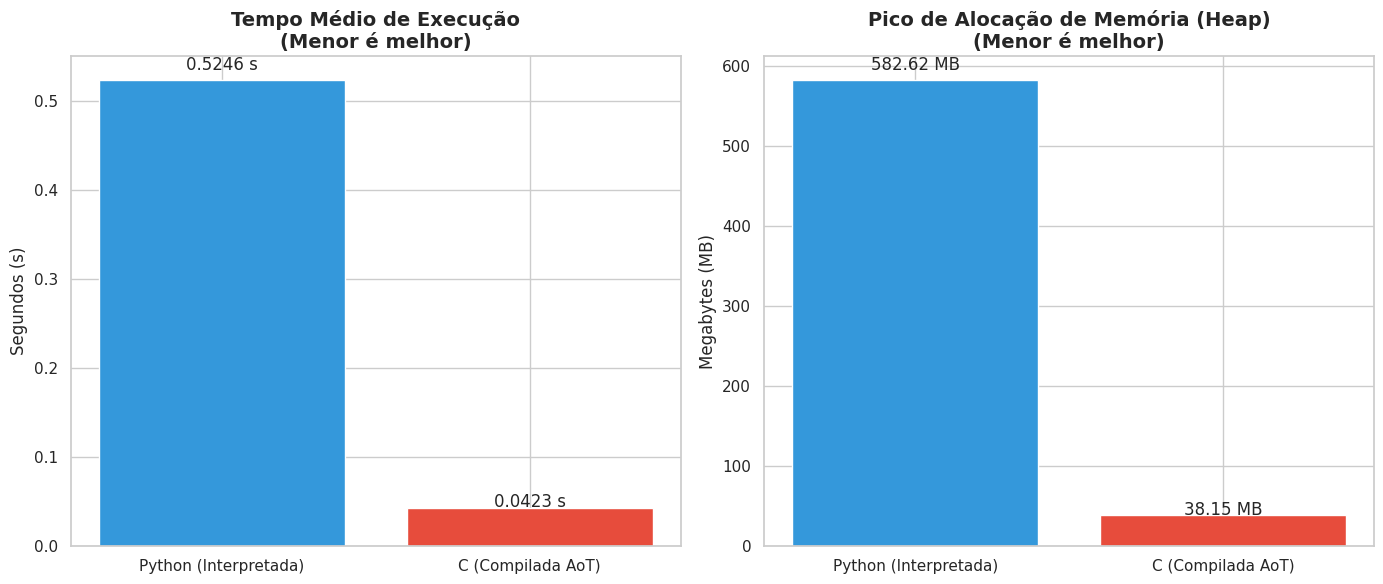

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Garantindo que o numpy esteja disponível

# --- Configuração de estilo dos gráficos ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

linguagens = ['Python (Interpretada)', 'C (Compilada AoT)']
cores = ['#3498db', '#e74c3c']

# --- Tratamento de Dados ---
# Função auxiliar para extrair o valor único (escalar) se for uma lista
def obter_valor_unico(valor):
    if hasattr(valor, '__len__') and not isinstance(valor, str):
        return float(np.max(valor))
    return float(valor)

# Garantir que está usando números únicos e não sequências
val_py_mem = obter_valor_unico(py_mem_mb)
val_c_mem = obter_valor_unico(c_mem_mb)

# --- Gráfico 1: Tempo de Execução ---
axes[0].bar(linguagens, [py_time_sec, c_time_sec], color=cores)
axes[0].set_title('Tempo Médio de Execução\n(Menor é melhor)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Segundos (s)', fontsize=12)

# Adiciona os rótulos de texto (labels) acima das barras
for i, v in enumerate([py_time_sec, c_time_sec]):
    axes[0].text(i, v + (v * 0.02), f"{v:.4f} s", ha='center', fontsize=12)

# --- Gráfico 2: Consumo de Memória (Heap) ---
axes[1].bar(linguagens, [val_py_mem, val_c_mem], color=cores)
axes[1].set_title('Pico de Alocação de Memória (Heap)\n(Menor é melhor)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Megabytes (MB)', fontsize=12)

# Adiciona os rótulos de texto com os valores tratados
for i, v in enumerate([val_py_mem, val_c_mem]):
    axes[1].text(i, v + (v * 0.02), f"{v:.2f} MB", ha='center', fontsize=12)

# --- Finalização e Salvamento ---
plt.tight_layout()

# Salvando a imagem na pasta /img para ser inserida no artigo
caminho_imagem = '../img/benchmarks_compiladores_corrigido.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_imagem}")

plt.show()